#**📍 Data Exploration**

##**IMPORTS**

In [1]:
# Data manipulation and processing
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.dates import DateFormatter
import matplotlib.dates as mdates

# Networking
import networkx as nx
from collections import Counter, defaultdict

# Statistics
from scipy import stats
from scipy.stats import describe, skew, kurtosis

import warnings
warnings.filterwarnings('ignore')

In [2]:
url = "https://raw.githubusercontent.com/Zhecto/KaizenTek-Data-Mining/main/contact%20graph%20analysis/notebooks/datasets/compiled_merged_dataset/final_contact_tracing_data.csv"
df = pd.read_csv(url)
print("\n" + "="*80)
print("DATASET OVERVIEW")
print("="*80)
print(f"Dataset Shape: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"Dataset shape: {df.shape}")
display(df.head())


DATASET OVERVIEW
Dataset Shape: 346845 rows × 13 columns
Dataset shape: (346845, 13)


,timestamp,person_A,person_B,group_A,group_B,time_seconds,time_minutes,time_hours,source_file,datetime,date,hour,timestamp_norm
0,28820.0,492,938,SRH,DMCT,576400,9606.666667,160.111111,tij_InVS13_merged,2009-04-17 08:00:20,2009-04-17,08:00:20,0.00000
1,28840.0,164,779,SSI,DST,576800,9613.333333,160.222222,tij_InVS15,2009-04-17 08:00:40,2009-04-17,08:00:40,0.00002
2,28840.0,574,1362,DMI,DST,576800,9613.333333,160.222222,tij_InVS15,2009-04-17 08:00:40,2009-04-17,08:00:40,0.00002
3,28860.0,117,429,SFLE,DST,577200,9620.000000,160.333333,tij_InVS15,2009-04-17 08:01:00,2009-04-17,08:01:00,0.00004
4,28860.0,267,272,DSE,DSE,577200,9620.000000,160.333333,tij_InVS13_merged,2009-04-17 08:01:00,2009-04-17,08:01:00,0.00004


## **Network Structure Analysis - Basic Statistics**

In [3]:
# Unique nodes
unique_persons = set(df['person_A'].unique()) | set(df['person_B'].unique())
num_nodes = len(unique_persons)

print(f"\nNumber of unique persons (nodes): {num_nodes}")
print(f"Total contact records (temporal edges): {len(df)}")


Number of unique persons (nodes): 794
Total contact records (temporal edges): 346845


In [4]:
# Temporal span
df['datetime'] = pd.to_datetime(df['datetime'])

time_min = df['datetime'].min()
time_max = df['datetime'].max()
duration_hours = (time_max - time_min).total_seconds() / 3600
print(f"Temporal span: {time_min} to {time_max}")
print(f"Duration: {duration_hours:.2f} hours")

Temporal span: 2009-04-17 08:00:20 to 2009-04-28 19:59:40
Duration: 275.99 hours


In [5]:
# Unique groups
unique_groups = set(df['group_A'].unique()) | set(df['group_B'].unique())
# Remove any non-string values (like NaN) before sorting
unique_groups_sorted = sorted([group for group in unique_groups if isinstance(group, str)])
num_groups = len(unique_groups_sorted)
print(f"\nNumber of unique groups: {num_groups}")
print(f"Groups: {unique_groups_sorted}")


Number of unique groups: 18
Groups: ['BIO', 'DCAR', 'DG', 'DISQ', 'DMCT', 'DMI', 'DSE', 'DST', 'MP', 'MPst', 'PC', 'PCst', 'PSIst', 'SCOM', 'SDOC', 'SFLE', 'SRH', 'SSI']


In [6]:
# Contact statistics
print(f"\nContact Statistics:")
print(f"  Total contact records: {len(df)}")
print(f"  Unique person pairs: {len(df[['person_A', 'person_B']].drop_duplicates())}")
print(f"  Unique undirected pairs: {len(df.groupby(by=['person_A', 'person_B'], sort=False).count())}")


Contact Statistics:
  Total contact records: 346845
  Unique person pairs: 20346
  Unique undirected pairs: 20346


##**Degree Distribution Analysis**

In [7]:
# Calculate degree (contact frequency per person)
degree_count_a = df['person_A'].value_counts()
degree_count_b = df['person_B'].value_counts()
degree_count = pd.concat([degree_count_a, degree_count_b], axis=1).fillna(0).sum(axis=1)

print("\n" + "="*80)
print("DEGREE DISTRIBUTION ANALYSIS")
print("="*80)

print(f"\nDegree Statistics:")
print(f"  Mean: {degree_count.mean():.2f}")
print(f"  Median: {degree_count.median():.2f}")
print(f"  Std Dev: {degree_count.std():.2f}")
print(f"  Min: {degree_count.min():.0f}")
print(f"  Max: {degree_count.max():.0f}")
print(f"  Skewness: {skew(degree_count):.4f}")
print(f"  Kurtosis: {kurtosis(degree_count):.4f}")


DEGREE DISTRIBUTION ANALYSIS

Degree Statistics:
  Mean: 873.66
  Median: 501.00
  Std Dev: 954.97
  Min: 2
  Max: 6072
  Skewness: 1.9332
  Kurtosis: 4.5438


In [8]:
# Percentiles
percentiles = [25, 50, 75, 90, 95, 99]
print(f"\nPercentiles:")
for p in percentiles:
    value = np.percentile(degree_count, p)
    print(f"  {p}th: {value:.2f}")


Percentiles:
  25th: 189.25
  50th: 501.00
  75th: 1260.75
  90th: 2127.00
  95th: 2790.20
  99th: 4493.80


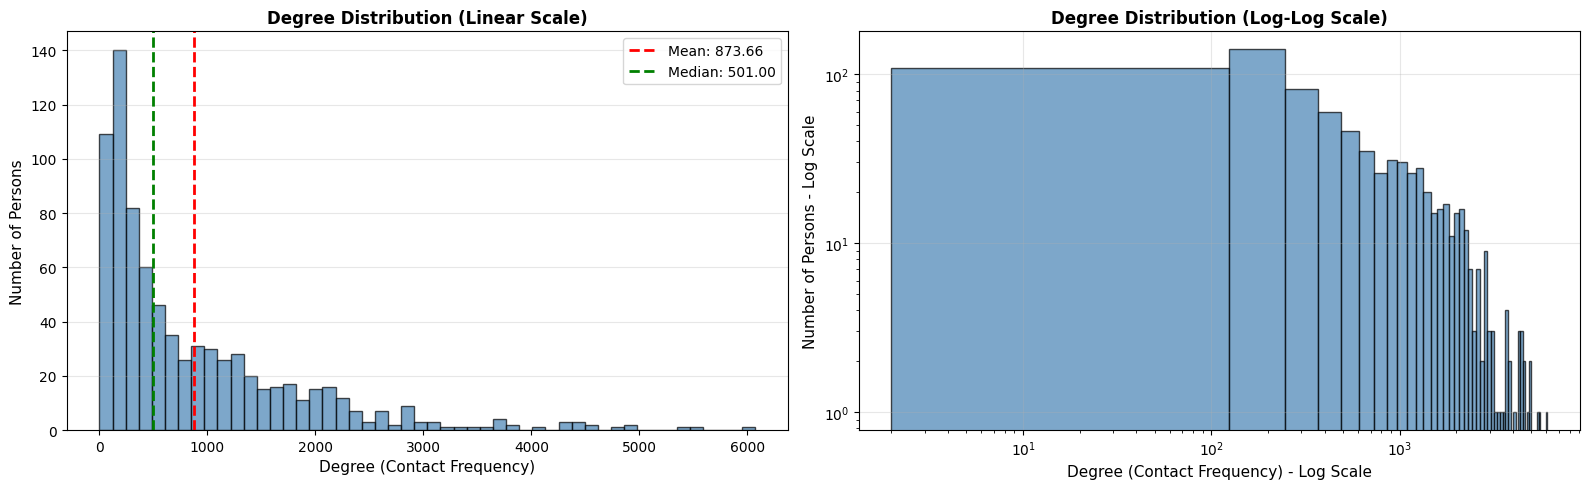

In [9]:
# Visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].hist(degree_count, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].axvline(degree_count.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {degree_count.mean():.2f}')
axes[0].axvline(degree_count.median(), color='green', linestyle='--', linewidth=2, label=f'Median: {degree_count.median():.2f}')
axes[0].set_xlabel('Degree (Contact Frequency)', fontsize=11)
axes[0].set_ylabel('Number of Persons', fontsize=11)
axes[0].set_title('Degree Distribution (Linear Scale)', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

axes[1].hist(degree_count, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[1].set_xlabel('Degree (Contact Frequency) - Log Scale', fontsize=11)
axes[1].set_ylabel('Number of Persons - Log Scale', fontsize=11)
axes[1].set_title('Degree Distribution (Log-Log Scale)', fontsize=12, fontweight='bold')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [10]:
print(f"\nTop 15 Most Connected Persons:")
top_degree = degree_count.nlargest(15)
for idx, (person, count) in enumerate(top_degree.items(), 1):
    print(f"  {idx:2d}. Person {person:4} : {count:6.0f} contacts")


Top 15 Most Connected Persons:
   1. Person  884 :   6072 contacts
   2. Person  603 :   5533 contacts
   3. Person  122 :   5365 contacts
   4. Person  275 :   4952 contacts
   5. Person  513 :   4892 contacts
   6. Person  634 :   4738 contacts
   7. Person  147 :   4613 contacts
   8. Person   39 :   4531 contacts
   9. Person  366 :   4491 contacts
  10. Person    3 :   4412 contacts
  11. Person  267 :   4389 contacts
  12. Person 1359 :   4338 contacts
  13. Person  119 :   4290 contacts
  14. Person  255 :   4258 contacts
  15. Person 1512 :   4106 contacts


##**Group Homophily Analysis**

In [11]:
# Create homophily categories
df['contact_type'] = df.apply(
    lambda row: 'Intra-group' if row['group_A'] == row['group_B'] else 'Inter-group',
    axis=1
)

# Homophily statistics
homophily_counts = df['contact_type'].value_counts()
homophily_pct = df['contact_type'].value_counts(normalize=True) * 100

print(f"\nContact Type Distribution:")
for ctype in homophily_counts.index:
    print(f"  {ctype:15}: {homophily_counts[ctype]:7} ({homophily_pct[ctype]:6.2f}%)")


Contact Type Distribution:
  Intra-group    :  249240 ( 71.86%)
  Inter-group    :   97605 ( 28.14%)


In [12]:
# Group size distribution
group_persons_a = df['group_A'].value_counts()
group_persons_b = df['group_B'].value_counts()
group_contacts = group_persons_a.add(group_persons_b, fill_value=0).sort_values(ascending=False)

print(f"\nGroup Contact Distribution:")
for group, count in group_contacts.items():
    print(f"  {group:10}: {count:7.0f} contacts")


Group Contact Distribution:
  BIO       :  146155 contacts
  MPst      :   84447 contacts
  PC        :   53357 contacts
  PCst      :   41580 contacts
  DMI       :   36148 contacts
  MP        :   33440 contacts
  DSE       :   30960 contacts
  DMCT      :   24962 contacts
  DISQ      :   24283 contacts
  DST       :   24228 contacts
  PSIst     :   18037 contacts
  SRH       :   12262 contacts
  DCAR      :   10471 contacts
  SFLE      :    5233 contacts
  SSI       :    2857 contacts
  SCOM      :    2749 contacts
  SDOC      :    1498 contacts
  DG        :     501 contacts


In [13]:
# Inter-group contact matrix
print(f"\nInter-group Contact Matrix:")
inter_group_matrix = pd.crosstab(df['group_A'], df['group_B'])
print(inter_group_matrix)


Inter-group Contact Matrix:
group_B    BIO  DCAR  DG  DISQ  DMCT    DMI    DSE   DST     MP   MPst     PC  \
group_A                                                                         
BIO      72434     0   0     0     0      0      0     0     79    323     88   
DCAR         0  3768  11    85    72    442    166   260      0      0      0   
DG           0    44   6   100     5     93      1    53      0      0      0   
DISQ         0   164  67  9852   766    342    284   364      0      0      0   
DMCT         0    53   0   384  9888    355    789   549      0      0      0   
DMI          0   505  23   269   339  14945    308   757      0      0      0   
DSE          0    44   4   956   625    272  12348   270      0      0      0   
DST          0   298   5   244   463   1158   1038  8549      0      0      0   
MP          47     0   0     0     0      0      0     0  15070   2070     13   
MPst        11     0   0     0     0      0      0     0    709  40273      8   

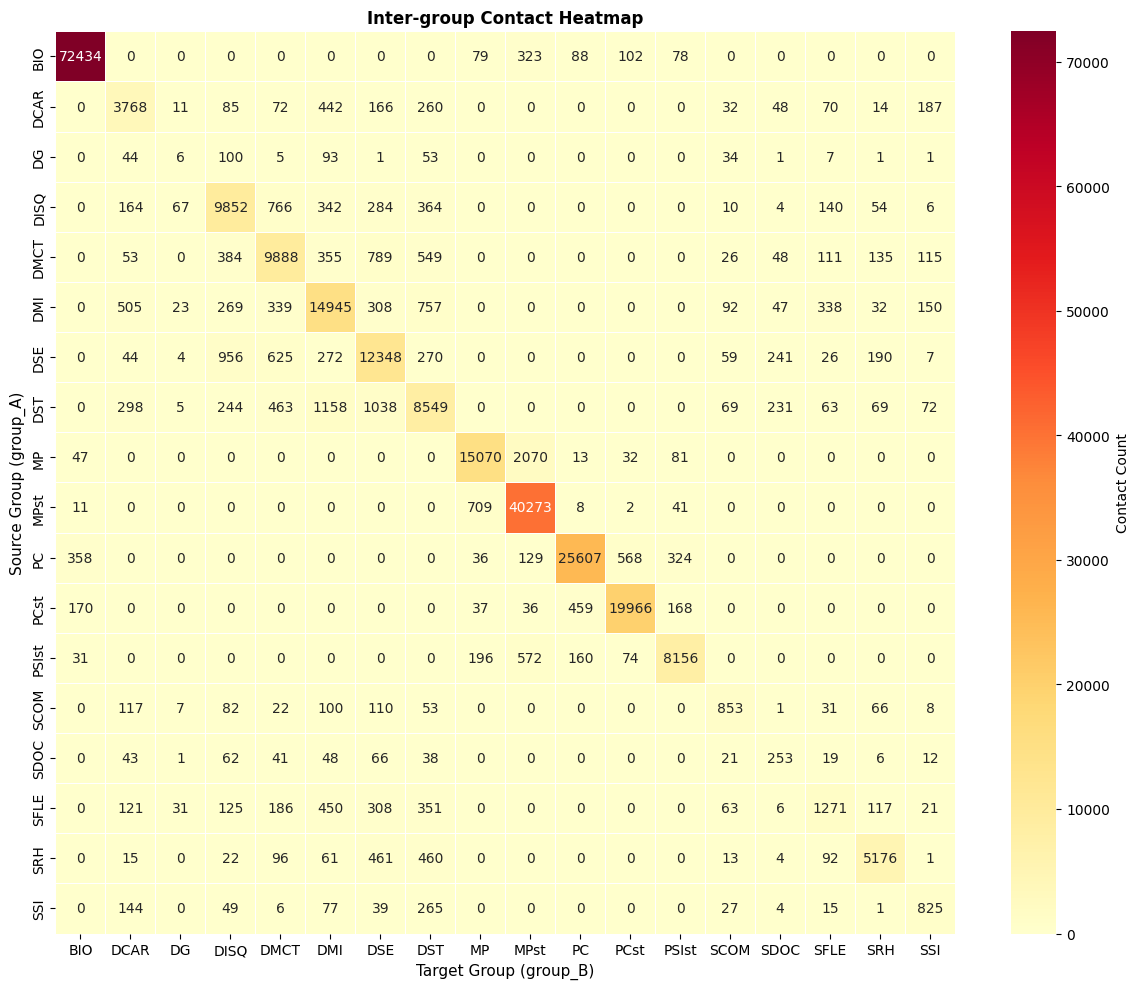

In [14]:
# Visualize inter-group contacts
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(inter_group_matrix, annot=True, fmt='d', cmap='YlOrRd',
            cbar_kws={'label': 'Contact Count'}, ax=ax, linewidths=0.5)
ax.set_title('Inter-group Contact Heatmap', fontsize=12, fontweight='bold')
ax.set_xlabel('Target Group (group_B)', fontsize=11)
ax.set_ylabel('Source Group (group_A)', fontsize=11)
plt.tight_layout()
plt.show()

##**Temporal Pattern Analysis - Hourly Distribution**

In [15]:
print("\n" + "="*80)
print("TEMPORAL PATTERN ANALYSIS - HOURLY DISTRIBUTION")
print("="*80)

# Extract hour from datetime
df['hour'] = df['datetime'].dt.hour

# Hourly contact distribution
hourly_contacts = df['hour'].value_counts().sort_index()

print(f"\nHourly Contact Distribution:")
for hour, count in hourly_contacts.items():
    print(f"  Hour {hour:2d}:00 - {hour:2d}:59 : {count:6} contacts ({count/len(df)*100:5.2f}%)")


TEMPORAL PATTERN ANALYSIS - HOURLY DISTRIBUTION

Hourly Contact Distribution:
  Hour  8:00 -  8:59 :  24639 contacts ( 7.10%)
  Hour  9:00 -  9:59 :  34461 contacts ( 9.94%)
  Hour 10:00 - 10:59 :  41149 contacts (11.86%)
  Hour 11:00 - 11:59 :  47693 contacts (13.75%)
  Hour 12:00 - 12:59 :  39069 contacts (11.26%)
  Hour 13:00 - 13:59 :  40414 contacts (11.65%)
  Hour 14:00 - 14:59 :  38050 contacts (10.97%)
  Hour 15:00 - 15:59 :  31603 contacts ( 9.11%)
  Hour 16:00 - 16:59 :  31447 contacts ( 9.07%)
  Hour 17:00 - 17:59 :  10108 contacts ( 2.91%)
  Hour 18:00 - 18:59 :   5256 contacts ( 1.52%)
  Hour 19:00 - 19:59 :   2785 contacts ( 0.80%)
  Hour 20:00 - 20:59 :    124 contacts ( 0.04%)
  Hour 21:00 - 21:59 :     47 contacts ( 0.01%)


In [16]:
# Hourly statistics
print(f"\nHourly Statistics:")
print(f"  Mean contacts per hour: {hourly_contacts.mean():.2f}")
print(f"  Median contacts per hour: {hourly_contacts.median():.2f}")
print(f"  Peak hour: {hourly_contacts.idxmax()}:00 with {hourly_contacts.max()} contacts")
print(f"  Lowest hour: {hourly_contacts.idxmin()}:00 with {hourly_contacts.min()} contacts")
print(f"  Std Dev: {hourly_contacts.std():.2f}")


Hourly Statistics:
  Mean contacts per hour: 24774.64
  Median contacts per hour: 31525.00
  Peak hour: 11:00 with 47693 contacts
  Lowest hour: 21:00 with 47 contacts
  Std Dev: 17325.52


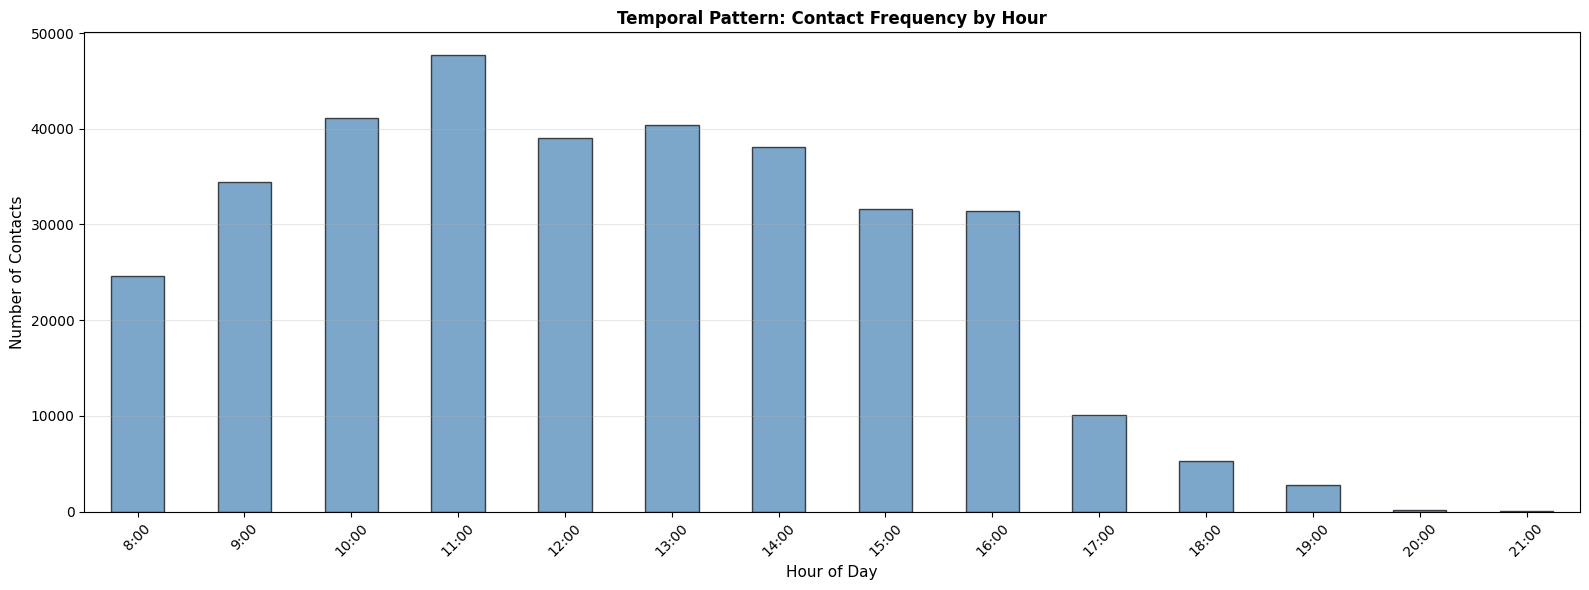

In [17]:
# Visualize hourly pattern
fig, ax = plt.subplots(figsize=(16, 6))
hourly_contacts.plot(kind='bar', ax=ax, color='steelblue', edgecolor='black', alpha=0.7)
ax.set_xlabel('Hour of Day', fontsize=11)
ax.set_ylabel('Number of Contacts', fontsize=11)
ax.set_title('Temporal Pattern: Contact Frequency by Hour', fontsize=12, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
ax.set_xticks(range(len(hourly_contacts.index))) # Set ticks at the position of each bar
ax.set_xticklabels([f'{i}:00' for i in hourly_contacts.index], rotation=45) # Set labels using the actual hours
plt.tight_layout()
plt.show()

##**Temporal Burstiness and Inter-event Time Distribution**

In [18]:
# Sort by timestamp for inter-event analysis
df_sorted = df.sort_values('timestamp').reset_index(drop=True)

# Calculate inter-event times (time between consecutive contacts)
inter_event_times = np.diff(df_sorted['timestamp'].values)

print("\n" + "="*80)
print("TEMPORAL BURSTINESS AND INTER-EVENT TIME DISTRIBUTION")
print("="*80)

print(f"\nInter-event Time Distribution (seconds):")
print(f"  Mean: {inter_event_times.mean():.2f}s")
print(f"  Median: {np.median(inter_event_times):.2f}s")
print(f"  Std Dev: {inter_event_times.std():.2f}s")
print(f"  Min: {inter_event_times.min():.2f}s")
print(f"  Max: {inter_event_times.max():.2f}s")
print(f"  Skewness: {skew(inter_event_times):.4f}")


TEMPORAL BURSTINESS AND INTER-EVENT TIME DISTRIBUTION

Inter-event Time Distribution (seconds):
  Mean: 2.86s
  Median: 0.00s
  Std Dev: 426.63s
  Min: 0.00s
  Max: 218600.00s
  Skewness: 412.8403


In [19]:
# Burstiness index
mean_iet = inter_event_times.mean()
std_iet = inter_event_times.std()
burstiness = (std_iet - mean_iet) / (std_iet + mean_iet)

print(f"\nTemporal Burstiness Index: {burstiness:.4f}")
print("  Interpretation:")
print(f"    Range: [-1, 1]")
print(f"    0 = random (Poisson)")
print(f"    >0 = bursty (clustered)")
print(f"    <0 = regular (evenly spaced)")



Temporal Burstiness Index: 0.9867
  Interpretation:
    Range: [-1, 1]
    0 = random (Poisson)
    >0 = bursty (clustered)
    <0 = regular (evenly spaced)


##**Temporal Coverage and Gaps**

In [20]:
print("\n" + "="*80)
print("TEMPORAL COVERAGE AND GAPS")
print("="*80)

# Group contacts by time windows
df['time_window_1min'] = df['datetime'].dt.floor('1min')
df['time_window_1hour'] = df['datetime'].dt.floor('1H')
df['date'] = df['datetime'].dt.date

# Contacts per minute
contacts_per_minute = df.groupby('time_window_1min').size()
print(f"\nContacts per Minute:")
print(f"  Total time windows (minutes) with contacts: {len(contacts_per_minute)}")
print(f"  Mean contacts per minute: {contacts_per_minute.mean():.2f}")
print(f"  Max contacts in a minute: {contacts_per_minute.max()}")


TEMPORAL COVERAGE AND GAPS

Contacts per Minute:
  Total time windows (minutes) with contacts: 6679
  Mean contacts per minute: 51.93
  Max contacts in a minute: 388


In [21]:
# Contacts per hour
contacts_per_hour = df.groupby('time_window_1hour').size()
print(f"\nContacts per Hour:")
print(f"  Total time windows (hours) with contacts: {len(contacts_per_hour)}")
print(f"  Mean contacts per hour: {contacts_per_hour.mean():.2f}")
print(f"  Max contacts in an hour: {contacts_per_hour.max()}")

# Contacts per day
contacts_per_day = df.groupby('date').size()
print(f"\nContacts per Day:")
print(f"  Total time windows (days) with contacts: {len(contacts_per_day)}")
print(f"  Mean contacts per day: {contacts_per_day.mean():.2f}")
print(f"  Max contacts in a day: {contacts_per_day.max()}")


Contacts per Hour:
  Total time windows (hours) with contacts: 122
  Mean contacts per hour: 2842.99
  Max contacts in an hour: 15465

Contacts per Day:
  Total time windows (days) with contacts: 10
  Mean contacts per day: 34684.50
  Max contacts in a day: 87876


In [22]:
# Contacts per date
contacts_per_date = df.groupby('date').size()
print(f"\nContacts per Date:")
print(f"  Total dates: {len(contacts_per_date)}")
print(f"  Mean contacts per date: {contacts_per_date.mean():.2f}")



Contacts per Date:
  Total dates: 10
  Mean contacts per date: 34684.50


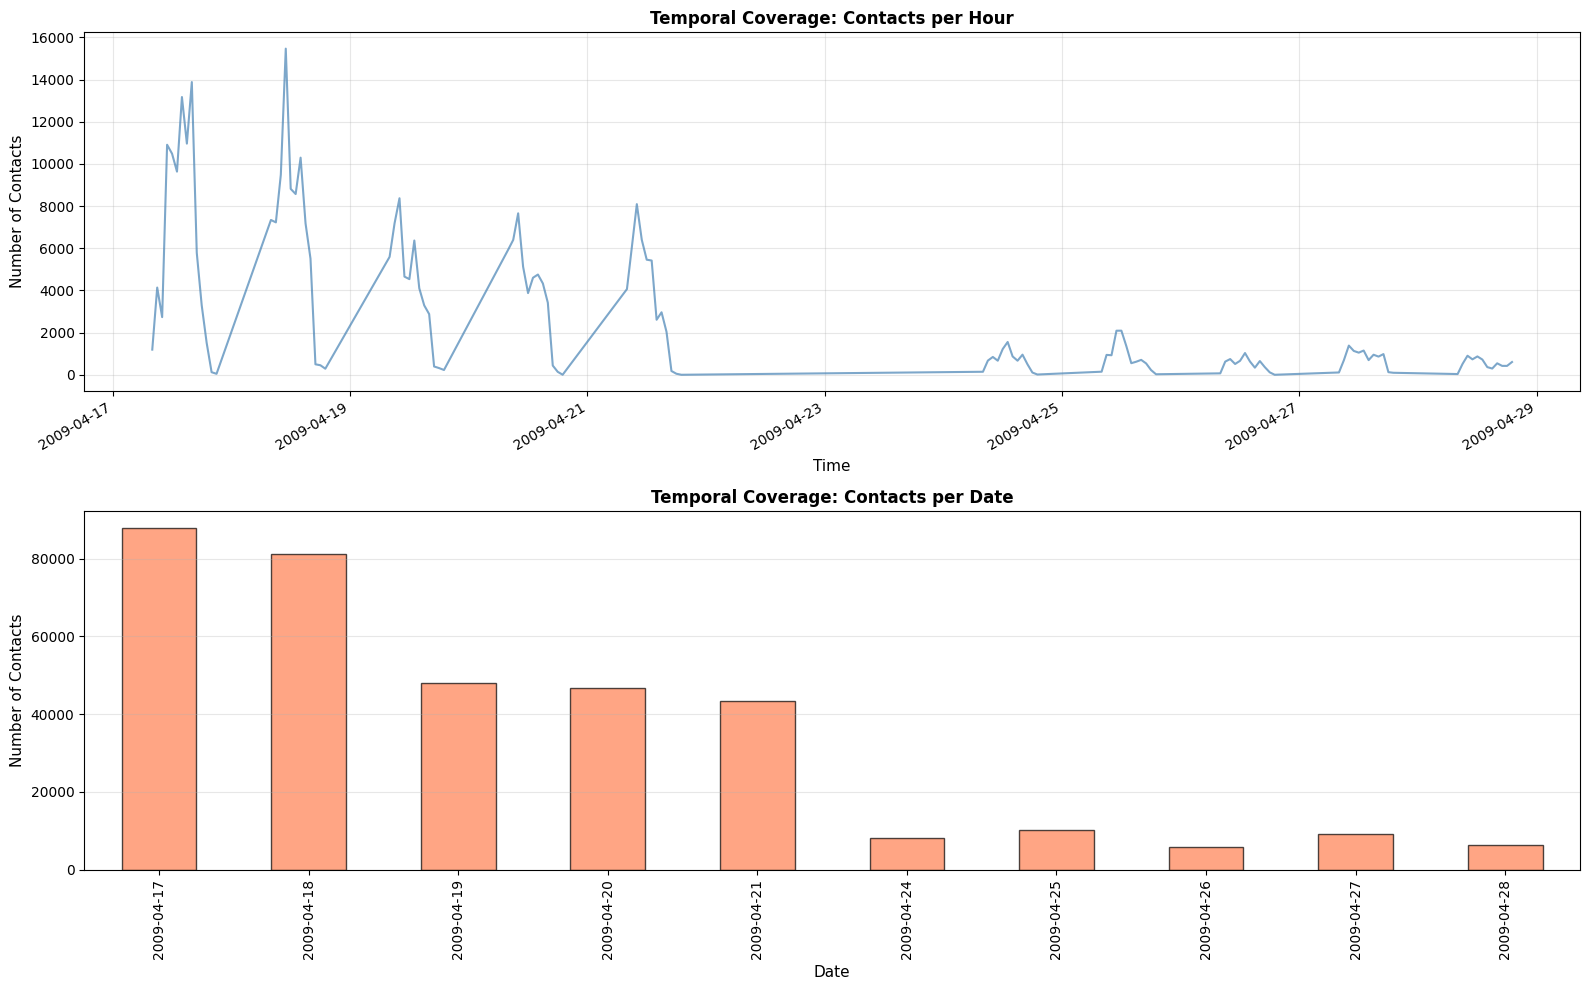

In [23]:
# Visualize temporal coverage
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# Hourly coverage
contacts_per_hour.plot(ax=axes[0], color='steelblue', alpha=0.7, linewidth=1.5)
axes[0].set_xlabel('Time', fontsize=11)
axes[0].set_ylabel('Number of Contacts', fontsize=11)
axes[0].set_title('Temporal Coverage: Contacts per Hour', fontsize=12, fontweight='bold')
axes[0].grid(alpha=0.3)

# Daily coverage
contacts_per_date.plot(ax=axes[1], kind='bar', color='coral', edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Date', fontsize=11)
axes[1].set_ylabel('Number of Contacts', fontsize=11)
axes[1].set_title('Temporal Coverage: Contacts per Date', fontsize=12, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## **Contacts per Person Distribution**

In [24]:
print("\n" + "="*80)
print("CONTACTS PER PERSON DISTRIBUTION")
print("="*80)

# Calculate total contacts per unique person
all_contacts_a = df['person_A'].value_counts()
all_contacts_b = df['person_B'].value_counts()

# Combine (accounting for potential duplicates)
contacts_per_person = all_contacts_a.add(all_contacts_b, fill_value=0)

print(f"\nContacts per Person Statistics:")
print(f"  Mean: {contacts_per_person.mean():.2f}")
print(f"  Median: {contacts_per_person.median():.2f}")
print(f"  Std Dev: {contacts_per_person.std():.2f}")
print(f"  Min: {contacts_per_person.min():.0f}")
print(f"  Max: {contacts_per_person.max():.0f}")
print(f"  Skewness: {skew(contacts_per_person):.4f}")


CONTACTS PER PERSON DISTRIBUTION

Contacts per Person Statistics:
  Mean: 873.66
  Median: 501.00
  Std Dev: 954.97
  Min: 2
  Max: 6072
  Skewness: 1.9332


In [25]:
# Identify isolated vs highly connected
isolated = (contacts_per_person <= 1).sum()
highly_connected = (contacts_per_person >= contacts_per_person.quantile(0.9)).sum()
moderate = ((contacts_per_person > 1) & (contacts_per_person < contacts_per_person.quantile(0.9))).sum()

print(f"\nPerson Categories:")
print(f"  Isolated persons (≤1 contact): {isolated} ({isolated/len(contacts_per_person)*100:.2f}%)")
print(f"  Moderate persons: {moderate} ({moderate/len(contacts_per_person)*100:.2f}%)")
print(f"  Highly connected (top 10%): {highly_connected} ({highly_connected/len(contacts_per_person)*100:.2f}%)")


Person Categories:
  Isolated persons (≤1 contact): 0 (0.00%)
  Moderate persons: 714 (89.92%)
  Highly connected (top 10%): 80 (10.08%)


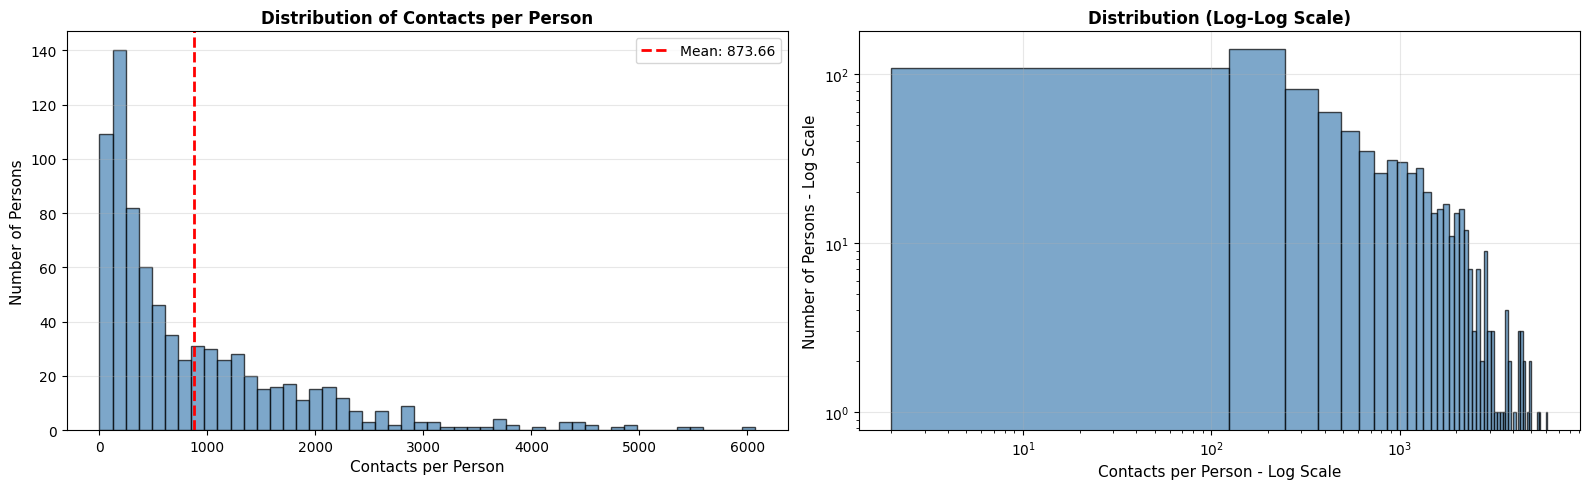

In [26]:
# Distribution visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].hist(contacts_per_person, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].axvline(contacts_per_person.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {contacts_per_person.mean():.2f}')
axes[0].set_xlabel('Contacts per Person', fontsize=11)
axes[0].set_ylabel('Number of Persons', fontsize=11)
axes[0].set_title('Distribution of Contacts per Person', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

axes[1].hist(contacts_per_person, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[1].set_xlabel('Contacts per Person - Log Scale', fontsize=11)
axes[1].set_ylabel('Number of Persons - Log Scale', fontsize=11)
axes[1].set_title('Distribution (Log-Log Scale)', fontsize=12, fontweight='bold')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

#**📍 Temporal Network Graph**

## **Build Temporal Network Graph - Node List**

In [27]:
print("\n" + "="*80)
print("GRAPH CONSTRUCTION: NODE LIST")
print("="*80)

# Create node list with attributes
nodes = []
for person in unique_persons:
    person_data = df[(df['person_A'] == person) | (df['person_B'] == person)]

    # Get group affiliation
    group_a = person_data['group_A'].mode()
    group_b = person_data['group_B'].mode()

    if len(group_a) > 0:
        group = group_a.values[0]
    elif len(group_b) > 0:
        group = group_b.values[0]
    else:
        group = 'Unknown'

    # Calculate contact statistics
    degree = len(person_data)
    first_contact = person_data['datetime'].min()
    last_contact = person_data['datetime'].max()
    duration_days = (last_contact - first_contact).total_seconds() / 86400

    nodes.append({
        'person_id': person,
        'group': group,
        'degree': degree,
        'first_contact': first_contact,
        'last_contact': last_contact,
        'duration_days': duration_days
    })

nodes_df = pd.DataFrame(nodes)

print(f"\nNode List Summary:")
print(f"  Total nodes: {len(nodes_df)}")
print(f"\nFirst 15 nodes:")
print(nodes_df.head(15).to_string(index=False))


GRAPH CONSTRUCTION: NODE LIST

Node List Summary:
  Total nodes: 794

First 15 nodes:
 person_id group  degree       first_contact        last_contact  duration_days
         1   BIO     367 2009-04-17 12:00:20 2009-04-18 10:08:20       0.922222
         3   BIO    4412 2009-04-17 08:15:20 2009-04-25 17:49:40       8.398843
         4 PSIst    1794 2009-04-17 12:13:00 2009-04-21 15:10:20       4.123148
         9    PC    1975 2009-04-17 12:00:20 2009-04-21 16:55:20       4.204861
        14  PCst     950 2009-04-17 08:54:20 2009-04-28 15:51:20      11.289583
        15    PC    2052 2009-04-17 08:01:40 2009-04-27 17:38:40      10.400694
        17  DMCT     104 2009-04-17 12:18:00 2009-04-28 09:44:40      10.893519
        18   SRH    1143 2009-04-17 09:27:20 2009-04-28 19:59:40      11.439120
        20  MPst    1779 2009-04-17 08:01:40 2009-04-28 17:23:00      11.389815
        21    PC    1140 2009-04-17 08:20:20 2009-04-28 12:09:40      11.159259
        27   BIO    1142 2009-04-

## **Build Temporal Network Graph - Edge List**

In [28]:
# Create comprehensive edge list with temporal information
edges = []

for idx, row in df.iterrows():
    edges.append({
        'source': row['person_A'],
        'target': row['person_B'],
        'timestamp': row['timestamp'],
        'datetime': row['datetime'],
        'source_group': row['group_A'],
        'target_group': row['group_B'],
        'contact_type': row['contact_type'],
        'duration': 20  # 20-second resolution
    })

edges_df = pd.DataFrame(edges)

print(f"\nTemporal Edge List Summary:")
print(f"  Total temporal edges: {len(edges_df)}")
print(f"  Temporal resolution: 20 seconds")
print(f"\nFirst 15 temporal edges:")
print(edges_df.head(15).to_string(index=False))


Temporal Edge List Summary:
  Total temporal edges: 346845
  Temporal resolution: 20 seconds

First 15 temporal edges:
 source  target  timestamp            datetime source_group target_group contact_type  duration
    492     938    28820.0 2009-04-17 08:00:20          SRH         DMCT  Inter-group        20
    164     779    28840.0 2009-04-17 08:00:40          SSI          DST  Inter-group        20
    574    1362    28840.0 2009-04-17 08:00:40          DMI          DST  Inter-group        20
    117     429    28860.0 2009-04-17 08:01:00         SFLE          DST  Inter-group        20
    267     272    28860.0 2009-04-17 08:01:00          DSE          DSE  Intra-group        20
    447     763    28860.0 2009-04-17 08:01:00          DMI          DMI  Intra-group        20
    447     763    28880.0 2009-04-17 08:01:20          DMI          DMI  Intra-group        20
    215    1414    28900.0 2009-04-17 08:01:40          DST         SFLE  Inter-group        20
     97    1204 

In [29]:
# Create aggregated edge list (for static network reference)
print(f"\nCreating aggregated edge list...")
aggregated_edges = df.groupby(['person_A', 'person_B']).agg({
    'timestamp': ['min', 'max', 'count'],
    'group_A': 'first',
    'group_B': 'first',
    'contact_type': 'first'
}).reset_index()

aggregated_edges.columns = ['source', 'target', 'first_contact_time', 'last_contact_time',
                             'contact_count', 'source_group', 'target_group', 'contact_type']

print(f"\nAggregated Edge List Summary:")
print(f"  Unique edges: {len(aggregated_edges)}")
print(f"  Mean contacts per pair: {aggregated_edges['contact_count'].mean():.2f}")
print(f"  Max contacts per pair: {aggregated_edges['contact_count'].max():.0f}")
print(f"  Min contacts per pair: {aggregated_edges['contact_count'].min():.0f}")
print(f"\nFirst 15 aggregated edges:")
print(aggregated_edges.head(15).to_string(index=False))


Creating aggregated edge list...

Aggregated Edge List Summary:
  Unique edges: 20346
  Mean contacts per pair: 17.05
  Max contacts per pair: 2949
  Min contacts per pair: 1

First 15 aggregated edges:
 source  target  first_contact_time  last_contact_time  contact_count source_group target_group contact_type
      1      55             43260.0            48400.0              8          BIO          BIO  Intra-group
      1      63             47140.0            51100.0              2          BIO          BIO  Intra-group
      1     101             51100.0            51100.0              1          BIO          BIO  Intra-group
      1     106             46460.0            51100.0              4          BIO          BIO  Intra-group
      1     117             43580.0           122900.0             19          BIO          BIO  Intra-group
      1     170             45820.0            54700.0              8          BIO          BIO  Intra-group
      1     179             54760